In [10]:
# performance testing for metapop1
import torch
import pickle
import os
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import numpy as np
import pandas as pd


def avgperformance(env, config, policy_printout=False):
    device = torch.device('cpu')  # Force CPU usage
    policytype = config['policytype']
    num_episodes = config['num_episodes']
    if policytype == 0: # Value iteration
        print( 'policy type: value iteration')
        with open(f'./value_iteration/VI_controller_setting{config["VIenvid"]}.pkl', 'rb') as f:
            ctrl = pickle.load(f)
        Policy = ctrl['policy']
        # reinitiate the environment
        settings = ctrl['envinfo']
        print(settings)
        env = metapop1(settings)
    elif policytype == 1: # ppo
        print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # find filename that starts with bestPolicyNetwork
        for filename in os.listdir(wd):
            if filename.startswith("bestPolicyNetwork"):
                model_path = os.path.join(wd, filename)
                break
        Policy = torch.load(model_path)
        # find filename that starts with bestPolicyrms
        for filename in os.listdir(wd):
            if filename.startswith("bestPolicyrms"):
                rms_path = os.path.join(wd, filename)
                break
        with open(rms_path, "rb") as f:
            rms = pickle.load(f)

        # re-initialize the environment
        with open(f'{wd}/config.txt', 'r') as f:
            lines = f.readlines()
        for line in lines:
            if 'envconfig' in line:
                obsvarline = line
                break
        # parse the dictionary string of envconfig and evaluate it to get the obsvars
        envconfigstr = obsvarline.split('envconfig: ')[1].strip()
        envconfigdict = eval(envconfigstr)
        env = metapop1(envconfigdict)


    elif policytype == 2: # heuristics
        if config['heuristics'] == 0:
            print( 'policy type: heuristics, no action')
        elif config['heuristics'] == 1:
            print( 'policy type: heuristics, full action')
        elif config['heuristics'] == 2:
            print( 'policy type: heuristics, random action')
    rewards = []
    avgconnectivity = []
    avgeprob = []
    avgcprob = []
    occfraction = []
    goodHfraction = []
    survivaltime = []
    restore_fraction = []
    supp_fraction = []
    for i in range(num_episodes):
        obs, state = env.reset()
        input = obs.copy()
        if policytype == 1:
            input = rms.normalize(input)
        done = False
        ep_reward = 0
        avgconnectivity_per_episode = []
        avgeprob_per_episode = []
        avgcprob_per_episode = []
        occfraction_per_episode = []
        goodHfraction_per_episode = []
        survivaltime_per_episode = []
        restore_fraction_per_episode = []
        supp_fraction_per_episode = []
        tt=0
        while not done:
            if policytype == 0:
                action = _act(env, Policy, input)
            elif policytype == 1:
                with torch.no_grad():

                    tensorinput = torch.tensor(input, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                    action = Policy.getaction(tensorinput, get_action_only=True)
                    action = torch.squeeze(action).cpu().detach().numpy()
            elif policytype == 2: # heuristics
                if config['heuristics'] == 0: # no action
                    action = np.zeros(env.aS_dim + env.aR_dim)
                elif config['heuristics'] == 1: # full action
                    aR = np.zeros(env.aR_dim)
                    rlen = min(env.kR, env.aR_dim)
                    aR[np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)] = 1
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    aS[np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 2: # random action
                    aR = np.zeros(env.aR_dim, dtype=int)
                    rlen = min(env.kR, env.aR_dim)
                    Ridx = np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)
                    aR[Ridx] = np.random.choice([0,1], size=rlen)
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    Sidx = np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)
                    aS[Sidx] = np.random.choice([0,1], size=slen)
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] in [3,4]: # supplement if X=0 or H=0 (if config=3, supplement only X=0 for config=4)and restore H=0's in the order of highest incoming weight sum.
                    aR = np.zeros(env.aR_dim, dtype=int)
                    aS = np.zeros(env.aS_dim, dtype=int)
                    X = env.state[:,env.oidx['X']] if env.dim2state == 1 else env.state[env.oidx['X']]
                    H = env.state[:,env.oidx['H']] if env.dim2state == 1 else env.state[env.oidx['H']]
                    incoming_weights = env.w.sum(axis=0)
                    if config['heuristics'] == 3:
                        sidx = np.where((X == 0) | (H == 0))[0]
                    else:
                        sidx = np.where(X == 0)[0]
                    aS[sidx] = 1
                    h0 = np.where(H == 0)[0]
                    if h0.size > 0:
                        h0_sorted = h0[np.argsort(incoming_weights[h0])[::-1]]
                        aR[h0_sorted[:env.kR]] = 1
                    action = np.concatenate((aR, aS))
            tt += 1
            if policy_printout:
                print(f't: {input[env.oidx["t"][0]]},  X: {input[env.oidx["X"]]}, aS: {action[env.aidx["aS"]]}, H: {input[env.oidx["H"]]}, Z: {input[env.oidx["Z"]]}, aR: {action[env.aidx["aR"]]}')
            obs, reward, done, info = env.step(action)
            input = env.obs.copy()
            if policytype == 1:
                input = rms.normalize(input)
            ep_reward += reward
            avgconnectivity_per_episode.append(np.mean(info['connectivity']))
            avgeprob_per_episode.append(np.mean(info['extinction_prob']))
            avgcprob_per_episode.append(np.mean(info['colonization_prob']))
            occfraction_per_episode.append(np.mean(info['occupied_fraction']))
            goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
            restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
            supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)
        avgconnectivity.append(np.mean(avgconnectivity_per_episode))
        avgeprob.append(np.mean(avgeprob_per_episode))
        avgcprob.append(np.mean(avgcprob_per_episode))
        occfraction.append(np.mean(occfraction_per_episode))
        goodHfraction.append(np.mean(goodHfraction_per_episode))
        survivaltime.append(tt)
        restore_fraction.append(np.mean(restore_fraction_per_episode))
        supp_fraction.append(np.mean(supp_fraction_per_episode))
        rewards.append(ep_reward)
        #if (i+1) % 100 == 0:
        #    print(f'Episode {i+1} done')
    summary = {'rewards': rewards, 'connectivity': avgconnectivity, 'extinction_prob': avgeprob, 'colonization_prob': avgcprob, 'occupied_fraction': occfraction, 'good_habitat_fraction': goodHfraction, 'survival_time': survivaltime, 'restore_fraction': restore_fraction, 'supp_fraction': supp_fraction}
    summary_df = pd.DataFrame(summary)
    
    print(f'patch num = {env.patchnum}')
    print(f'Average reward over {num_episodes} episodes: {np.mean(rewards):.2f}')
    print(f'Average connectivity: {np.mean(avgconnectivity):.2f}, Average extinction prob: {np.mean(avgeprob):.2f}, Average colonization prob: {np.mean(avgcprob):.2f}')
    print(f'Occupied fraction: Avg {np.mean(occfraction):.2f}, Std {np.std(occfraction):.2f}') 
    print(f'Good habitat fraction: Avg {np.mean(goodHfraction):.2f}, Std {np.std(goodHfraction):.2f}')
    print(f'Average survival time: {np.mean(survivaltime):.2f}')
    # add average in the first row of summary_df
    summary_df.loc[-1] = [np.mean(rewards), np.mean(avgconnectivity), np.mean(avgeprob), np.mean(avgcprob), np.mean(occfraction), np.mean(goodHfraction), np.mean(survivaltime), np.mean(restore_fraction), np.mean(supp_fraction)]
    summary_df.index = summary_df.index + 1  # shift index
    summary_df = summary_df.sort_index()  # sort by index
    # save as csv
    random_seed = np.random.randint(0, 100000000)
    summary_df.to_csv(f'./performance_summary/performance_summary_{random_seed}.csv', index=False)

    return summary


# policytype: 0 for value iteration, 1 for ppo, 2 for heuristics

config = {'policytype': 1, 'ppoparamset': 11, 'pposeed': 693224, 'VIenvid': 19, 'heuristics': 4, 'num_episodes': 1000}
settings = {'settingID': 18}
env = metapop1(settings)
summary = avgperformance(env,config=config, policy_printout=False)

#cost = [0.083]
#a0 = [0.1]
#for j in range(len(cost)):
#    for k in range(len(a0)):
#        perfs = []
#        for i in [0,3]:#range(4):
#            config = {'policytype': 2, 'envid': 5, 'POMDP': 0, 'heuristics': i, 'num_episodes': 1000}
#            settings = {'settingID': 14}
#            env = metapop1(settings)
#            env.cr = cost[j]
#            env.cs = cost[j]
#            env.alph0 = a0[k]
#            summary = avgperformance(env,config=config, policy_printout=False)
#            perfs.append(np.mean(summary['rewards']))
#        #print(f'cost: {cost[j]}, a0: {a0[k]}, performance: {perfs[0]:.2f}/{perfs[1]:.2f}/{perfs[2]:.2f}/{perfs[3]:.2f}')

policy type: PPO, seed: 693224, paramset: 11


C:\Users\Hyun\AppData\Local\Temp\ipykernel_37812\1622908749.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Policy = torch.load(model_path)


patch num = 5
Average reward over 1000 episodes: 5.48
Average connectivity: 1.23, Average extinction prob: 0.36, Average colonization prob: 0.13
Occupied fraction: Avg 0.60, Std 0.06
Good habitat fraction: Avg 0.59, Std 0.08
Average survival time: 27.92


(array([  4.,  37., 108., 232., 278., 214.,  96.,  28.,   2.,   1.]),
 array([-3.81 , -1.736,  0.338,  2.412,  4.486,  6.56 ,  8.634, 10.708,
        12.782, 14.856, 16.93 ]),
 <BarContainer object of 10 artists>)

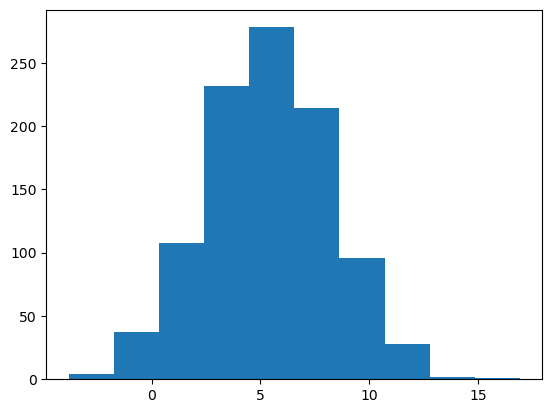

In [31]:
import os 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt

plt.hist(summary['rewards'])